In [50]:
# ============================================================
# MobileNetV3-Large (Keras 3 + TF 2.20 Compatible)
# Dermatology-Optimized Training Pipeline with Fine-Tuning
# ============================================================

import os
import keras
import tensorflow as tf
from keras import layers
from keras.utils import image_dataset_from_directory
from keras.applications import MobileNetV3Large
from keras.applications.mobilenet_v3 import preprocess_input


In [51]:
# ----------------------------
# GPU Check
# ----------------------------
if tf.config.list_physical_devices("GPU"):
    print("GPU detected. Using GPU.")
else:
    print("No GPU detected. Training will be slow.")

GPU detected. Using GPU.


In [52]:
TRAIN_DIR  = "dataset/train"
VAL_DIR    = "dataset/valid"
TEST_DIR   = "dataset/test"

OUTPUT_DIR = "./mobilenetv3_large_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [53]:
# ------------------------------------------------------------
# MIXED PRECISION
# ------------------------------------------------------------
if USE_MIXED_PRECISION:
    keras.mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled.")

Mixed precision enabled.


In [54]:
# ----------------------------
# HYPERPARAMETERS
# ----------------------------
IMAGE_SIZE = (224, 224)      # Optimal for MNv3
BATCH_SIZE = 32
NUM_CLASSES = 7
SEED = 42

EPOCHS = 12
LR = 1e-4
FT_LR = 1e-5         # Fine-tuning LR
AUTOTUNE = tf.data.AUTOTUNE
USE_MIXED_PRECISION = True

In [55]:
# ============================================================
# DATA LOADING
# ============================================================

train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

val_ds = image_dataset_from_directory(
    VAL_DIR,
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

test_ds = image_dataset_from_directory(
    TEST_DIR,
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 41995 files belonging to 7 classes.
Found 3499 files belonging to 7 classes.
Found 3499 files belonging to 7 classes.


In [56]:
# ============================================================
# SKIN-DISEASE OPTIMIZED AUGMENTATION
# ============================================================

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.12),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.15),
], name="derma_aug")

In [57]:
# ============================================================
# PREPROCESSING
# ============================================================

def preprocess_train(images, labels):
    images = preprocess_input(images)    # MobileNetV3 preprocess
    images = data_augmentation(images)
    return images, labels

def preprocess_eval(images, labels):
    images = preprocess_input(images)
    return images, labels

train_ds = train_ds.map(preprocess_train, AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.map(preprocess_eval, AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_ds.map(preprocess_eval, AUTOTUNE).prefetch(AUTOTUNE)

In [58]:
# ============================================================
# BUILD MODEL — MobileNetV3 Large
# ============================================================

base_model = MobileNetV3Large(
    include_top=False,
    weights="imagenet",
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
    pooling="avg"
)

base_model.trainable = False  # Freeze initially

inputs = keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
x = base_model(inputs, training=False)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

model = keras.Model(inputs, outputs, name="MobileNetV3-Large")
model.summary()

Model: "MobileNetV3-Large"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 960)            │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         6,727 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,003,079 (11.46 MB)

 Trainable params: 6,727 (26.28 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [59]:
# ============================================================
# COMPILE
# ============================================================

model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.SparseTopKCategoricalAccuracy(k=3),
        keras.metrics.SparseTopKCategoricalAccuracy(k=5),
    ]
)

# ============================================================
# CALLBACKS
# ============================================================

callbacks = [
    keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_DIR, "best_mobilenetv3_large.keras"),
        save_best_only=True,
        monitor="val_loss",
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),
]

# ============================================================
# TRAIN PHASE 1 (HEAD ONLY)
# ============================================================

print("\nTraining MobileNetV3-Large (head only)…\n")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)



Training MobileNetV3-Large (head only)…

Epoch 1/12


2025-11-15 10:27:18.471300: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3733', 164 bytes spill stores, 164 bytes spill loads

2025-11-15 10:27:18.518253: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3733', 164 bytes spill stores, 164 bytes spill loads



1310/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.2479 - loss: 2.0485 - sparse_top_k_categorical_accuracy: 0.5747 - sparse_top_k_categorical_accuracy_1: 0.8160

2025-11-15 10:28:54.795549: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3733', 8 bytes spill stores, 8 bytes spill loads

2025-11-15 10:28:54.797186: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3733', 12 bytes spill stores, 12 bytes spill loads



1313/1313 ━━━━━━━━━━━━━━━━━━━━ 157s 93ms/step - accuracy: 0.3342 - loss: 1.8030 - sparse_top_k_categorical_accuracy: 0.6597 - sparse_top_k_categorical_accuracy_1: 0.8669 - val_accuracy: 0.5139 - val_loss: 1.3323 - val_sparse_top_k_categorical_accuracy: 0.8142 - val_sparse_top_k_categorical_accuracy_1: 0.9448 - learning_rate: 1.0000e-04
Epoch 2/12
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 63s 47ms/step - accuracy: 0.4838 - loss: 1.4061 - sparse_top_k_categorical_accuracy: 0.7968 - sparse_top_k_categorical_accuracy_1: 0.9376 - val_accuracy: 0.5765 - val_loss: 1.1925 - val_sparse_top_k_categorical_accuracy: 0.8574 - val_sparse_top_k_categorical_accuracy_1: 0.9563 - learning_rate: 1.0000e-04
Epoch 3/12
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 63s 47ms/step - accuracy: 0.5343 - loss: 1.2907 - sparse_top_k_categorical_accuracy: 0.8290 - sparse_top_k_categorical_accuracy_1: 0.9490 - val_accuracy: 0.6047 - val_loss: 1.1280 - val_sparse_top_k_categorical_accuracy: 0.8677 - val_sparse_top_k_categorical_accuracy_1: 0

In [63]:
# ============================================================
# FINE-TUNING — UNFREEZE LAST N LAYERS
# ============================================================

def fine_tune(model, base_model, unfreeze_last=40, ft_epochs=10):

    print(f"\nFine-tuning MobileNetV3-Large: unfreezing last {unfreeze_last} layers…\n")

    # Freeze all
    for layer in base_model.layers:
        layer.trainable = False

    # Unfreeze last N layers
    for layer in base_model.layers[-unfreeze_last:]:
        layer.trainable = True

    model.compile(
        optimizer=keras.optimizers.Adam(FT_LR),
        loss="sparse_categorical_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.SparseTopKCategoricalAccuracy(k=3),
            keras.metrics.SparseTopKCategoricalAccuracy(k=5),
        ]
    )

    return model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=ft_epochs,
        callbacks=callbacks
    )

fine_history = fine_tune(model, base_model, unfreeze_last=50, ft_epochs=10)


Fine-tuning MobileNetV3-Large: unfreezing last 50 layers…

Epoch 1/10


1313/1313 ━━━━━━━━━━━━━━━━━━━━ 158s 90ms/step - accuracy: 0.7693 - loss: 0.6640 - sparse_top_k_categorical_accuracy: 0.9389 - sparse_top_k_categorical_accuracy_1: 0.9861 - val_accuracy: 0.7974 - val_loss: 0.6045 - val_sparse_top_k_categorical_accuracy: 0.9420 - val_sparse_top_k_categorical_accuracy_1: 0.9869 - learning_rate: 1.0000e-05
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 65s 49ms/step - accuracy: 0.7874 - loss: 0.6135 - sparse_top_k_categorical_accuracy: 0.9466 - sparse_top_k_categorical_accuracy_1: 0.9879 - val_accuracy: 0.8017 - val_loss: 0.5873 - val_sparse_top_k_categorical_accuracy: 0.9431 - val_sparse_top_k_categorical_accuracy_1: 0.9869 - learning_rate: 1.0000e-05
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 62s 47ms/step - accuracy: 0.7992 - loss: 0.5781 - sparse_top_k_categorical_accuracy: 0.9506 - sparse_top_k_categorical_accuracy_1: 0.9898 - val_accuracy: 0.8091 - val_loss: 0.5651 - val_sparse_top_k_categorical_accuracy: 0.9463 - val_sparse_top_k_categorical_accuracy_1: 0

In [64]:
# ============================================================
# FINAL EVALUATION
# ============================================================

print("\nEvaluating on test data…\n")
results = model.evaluate(test_ds)
print("Test results:", results)


Evaluating on test data…

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8531 - loss: 0.4457 - sparse_top_k_categorical_accuracy: 0.9608 - sparse_top_k_categorical_accuracy_1: 0.9920
Test results: [0.44571980834007263, 0.8531008958816528, 0.960845947265625, 0.960845947265625, 0.9919977188110352]


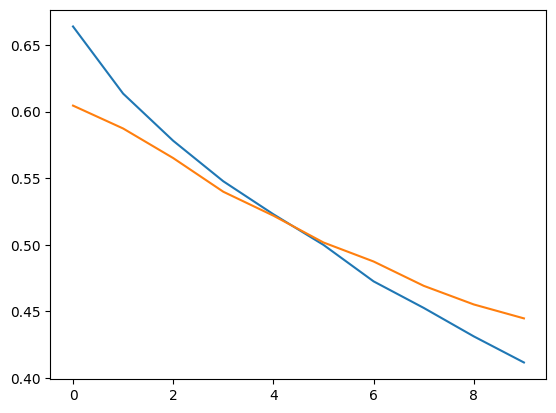

In [68]:
import matplotlib.pyplot as plt

plt.plot(fine_history.history['loss'])
plt.plot(fine_history.history['val_loss'])

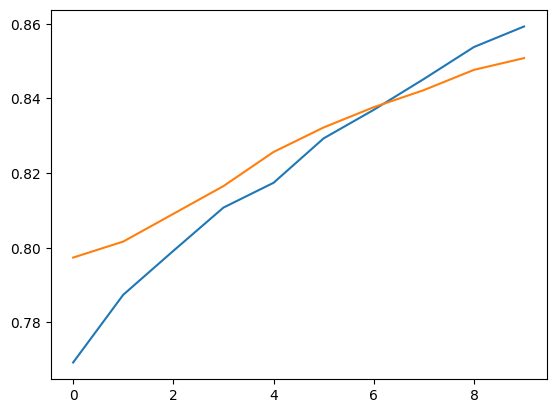

In [69]:
import matplotlib.pyplot as plt

plt.plot(fine_history.history['accuracy'])
plt.plot(fine_history.history['val_accuracy']) 

In [67]:
# ===========================================================
# SAVE FINAL MODEL
# ============================================================

model.save(os.path.join(OUTPUT_DIR, "mobilenetv3_large_final.keras"))
print("\nFinal model saved successfully!")


Final model saved successfully!
